# Diseño y cuantización de un filtro Raised Cosine

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Detectar raíz del proyecto de forma relativamente robusta
CURRENT_DIR = Path.cwd()

# Si el notebook corre desde TP1_FIR_IIR/fir, la raíz está dos niveles arriba
PROJECT_ROOT = CURRENT_DIR.parents[1]

UTILS_DIR = PROJECT_ROOT / "utils"

if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

print(f"Current dir : {CURRENT_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Utils dir   : {UTILS_DIR}")

Current dir : c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026\TP1_FIR_IIR\fir
Project root: c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026
Utils dir   : c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026\utils


In [3]:
from filtro_rc import RaisedCosineFilter
from fixed_point import FixedPointFormat, FixedPoint

## Filtro Root Raised Cosine

In [4]:
# Parámetros del filtro
ALPHA = 0.35     # Roll-off factor
SPAN = 6         # Duración del filtro en símbolos
SPS = 3          # Samples per symbol / oversampling
RRC = True       # False: Raised Cosine, True: Root Raised Cosine

In [5]:
rc_filter = RaisedCosineFilter(
    alpha=ALPHA,
    span=SPAN,
    sps=SPS,
    rrc=RRC
)

h_float = rc_filter.get_coefficients()

print(f"Número de taps: {len(h_float)}")
print(f"Coeficiente máximo: {np.max(h_float):.6f}")
print(f"Coeficiente mínimo: {np.min(h_float):.6f}")

Número de taps: 19
Coeficiente máximo: 1.095634
Coeficiente mínimo: -0.184197


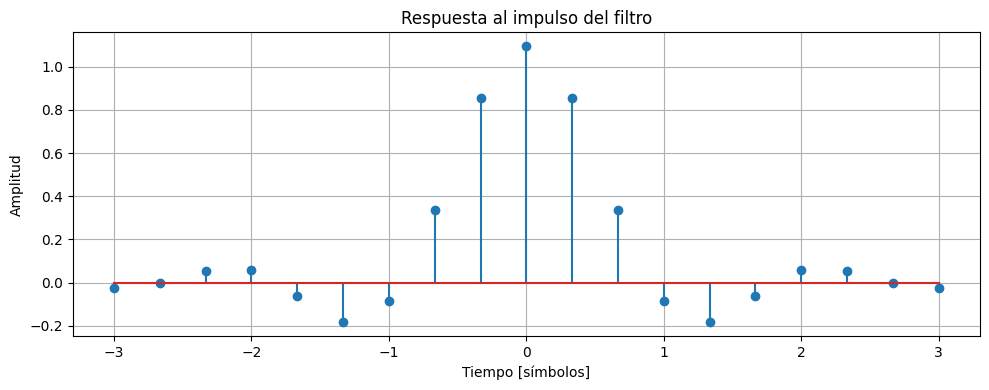

In [6]:
n = np.arange(len(h_float))
t_symbols = (n - len(h_float)//2) / SPS

plt.figure(figsize=(10, 4))
plt.stem(t_symbols, h_float)
plt.grid(True)
plt.xlabel("Tiempo [símbolos]")
plt.ylabel("Amplitud")
plt.title("Respuesta al impulso del filtro")
plt.tight_layout()
plt.show()

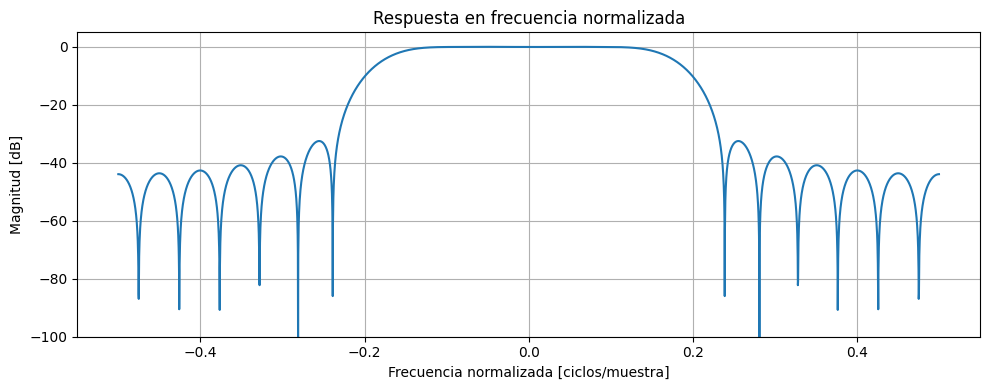

In [7]:
N_FFT = 4096

H = np.fft.fftshift(np.fft.fft(h_float, N_FFT))
H_mag_db = 20 * np.log10(np.abs(H) / np.max(np.abs(H)))

freq = np.linspace(-0.5, 0.5, N_FFT, endpoint=False)

plt.figure(figsize=(10, 4))
plt.plot(freq, H_mag_db)
plt.grid(True)
plt.xlabel("Frecuencia normalizada [ciclos/muestra]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia normalizada")
plt.ylim([-100, 5])
plt.tight_layout()
plt.show()

## Cuantización

#### Sweep de cuantización

In [8]:
formats = [
    FixedPointFormat(NB=8,  NBF=6),
    FixedPointFormat(NB=10, NBF=8),
    FixedPointFormat(NB=12, NBF=10),
    FixedPointFormat(NB=14, NBF=12),
    FixedPointFormat(NB=16, NBF=14),
]

In [9]:
import pandas as pd

sweep_results = []

quantized_coeffs = {}

for fmt in formats:
    h_q, h_int = fmt.quantize(
        h_float,
        rounding="trunc",
        overflow="saturate"
    )

    err = h_q - h_float

    label = f"Q({fmt.NB},{fmt.NBF})"
    quantized_coeffs[label] = {
        "format": fmt,
        "h_q": h_q,
        "h_int": h_int,
        "err": err,
    }

    sweep_results.append({
        "format": label,
        "NB": fmt.NB,
        "NBF": fmt.NBF,
        "NBI": fmt.NBI,
        "resolution": fmt.resolution,
        "real_min": fmt.real_min,
        "real_max": fmt.real_max,
        "mse": np.mean(err**2),
        "mae": np.mean(np.abs(err)),
        "max_abs_error": np.max(np.abs(err)),
        "mean_error": np.mean(err),
        "all_in_range": np.all(fmt.can_represent(h_float)),
    })

df_sweep = pd.DataFrame(sweep_results)
df_sweep

,format,NB,NBF,NBI,resolution,real_min,real_max,mse,mae,max_abs_error,mean_error,all_in_range
0,"Q(8,6)",8,6,2,0.015625,-2.0,1.984375,9.305672e-05,0.009012,0.013640,0.000548,True
1,"Q(10,8)",10,8,2,0.003906,-2.0,1.996094,5.168210e-06,0.002021,0.003788,0.000136,True
2,"Q(12,10)",12,10,2,0.000977,-2.0,1.999023,3.642135e-07,0.000531,0.000944,-0.000018,True
3,"Q(14,12)",14,12,2,0.000244,-2.0,1.999756,2.990719e-08,0.000158,0.000235,-0.000005,True
4,"Q(16,14)",16,14,2,0.000061,-2.0,1.999939,1.186337e-09,0.000030,0.000054,-0.000005,True


#### Respuesta al impulso

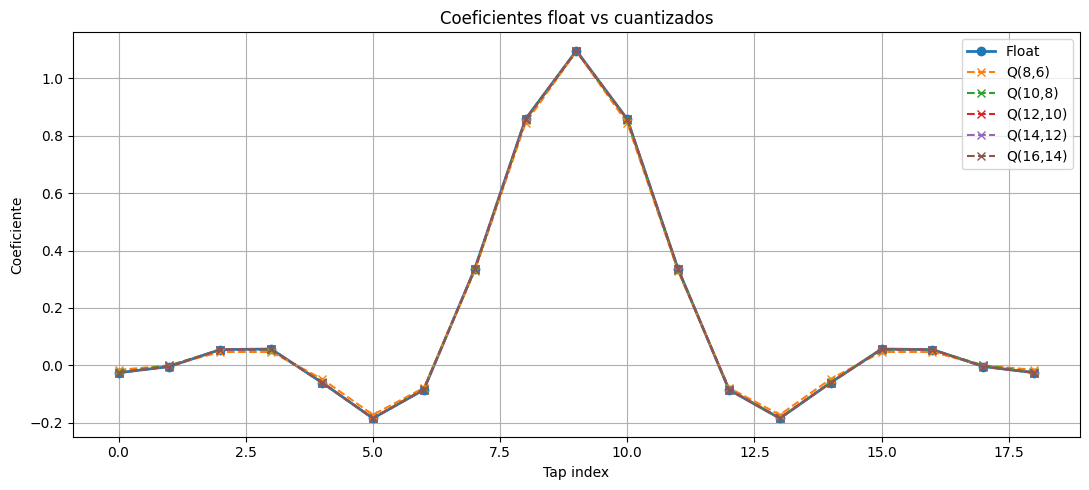

In [10]:
label_formats = [
    "Q(8,6)",
    "Q(10,8)",
    "Q(12,10)",
    "Q(14,12)",
    "Q(16,14)",
]

n = np.arange(len(h_float))

plt.figure(figsize=(11, 5))
plt.plot(n, h_float, marker="o", linewidth=2, label="Float")

for label in label_formats:
    h_q = quantized_coeffs[label]["h_q"]
    plt.plot(n, h_q, marker="x", linestyle="--", label=label)

plt.grid(True)
plt.xlabel("Tap index")
plt.ylabel("Coeficiente")
plt.title("Coeficientes float vs cuantizados")
plt.legend()
plt.tight_layout()
plt.show()

#### Error de cuantización

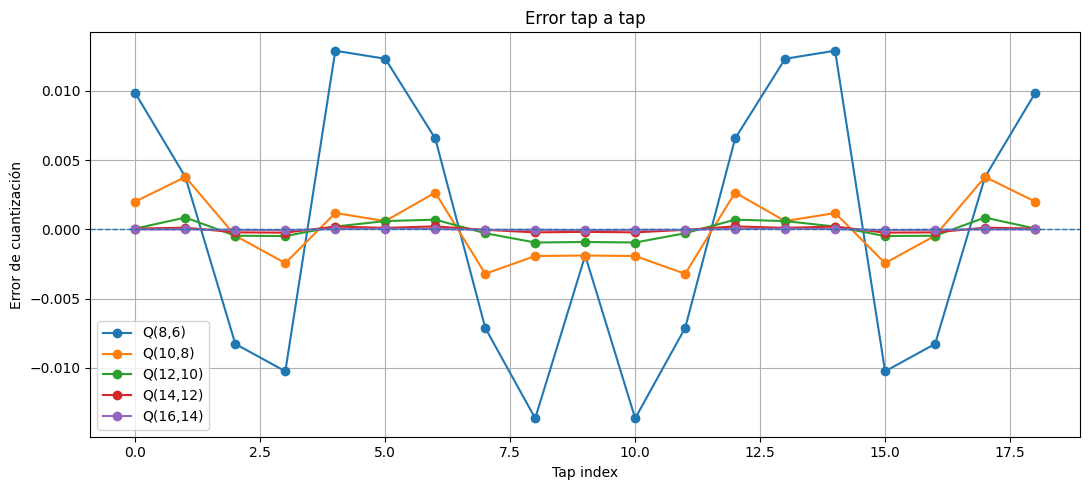

In [11]:
plt.figure(figsize=(11, 5))

for label in label_formats:
    err = quantized_coeffs[label]["err"]
    plt.plot(n, err, marker="o", label=label)

plt.axhline(0, linestyle="--", linewidth=1)
plt.grid(True)
plt.xlabel("Tap index")
plt.ylabel("Error de cuantización")
plt.title("Error tap a tap")
plt.legend()
plt.tight_layout()
plt.show()

#### Respuesta en frecuencia

In [12]:
def compute_freq_response(h, n_fft=4096):
    H = np.fft.fftshift(np.fft.fft(h, n_fft))
    H_mag = np.abs(H)
    H_mag_db = 20 * np.log10(H_mag / np.max(H_mag) + 1e-12)
    freq = np.linspace(-0.5, 0.5, n_fft, endpoint=False)
    return freq, H_mag_db

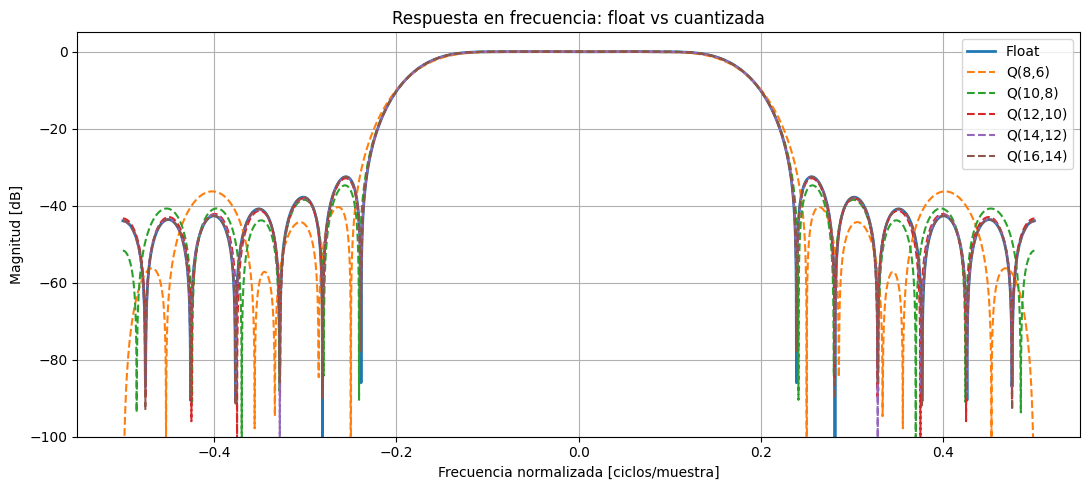

In [13]:
freq, H_float_db = compute_freq_response(h_float)

plt.figure(figsize=(11, 5))
plt.plot(freq, H_float_db, linewidth=2, label="Float")

for label in label_formats:
    h_q = quantized_coeffs[label]["h_q"]
    _, H_q_db = compute_freq_response(h_q)
    plt.plot(freq, H_q_db, linestyle="--", label=label)

plt.grid(True)
plt.xlabel("Frecuencia normalizada [ciclos/muestra]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: float vs cuantizada")
plt.ylim([-100, 5])
plt.legend()
plt.tight_layout()
plt.show()

#### Cuantización elegida

In [14]:
# Formatos fixed-point elegidos
# Convención: Q(NB, NBF), signed, con NBI = NB - NBF incluyendo signo.
NB_H  = 12
NBF_H = 10

ROUNDING = "trunc"
OVERFLOW = "saturate"

fmt_h = FixedPointFormat(NB=NB_H, NBF=NBF_H)  # Coeficientes

print("\nFormato de coeficientes")
fmt_h.info()

print(f"\nMáximo coeficiente: {np.max(h_float)}")
print(f"Mínimo coeficiente: {np.min(h_float)}")
print(f"Rango coeficientes : [{fmt_h.real_min}, {fmt_h.real_max}]")

if np.all(fmt_h.can_represent(h_float)):
    print(f"\nEl formato Q({fmt_h.NB},{fmt_h.NBF}) signed puede representar a los coeficientes.")
else:
    print(f"\nEl formato Q({fmt_h.NB},{fmt_h.NBF}) signed NO puede representar a los coeficientes.")

q_error = fmt_h.quantization_error(h_float, rounding=ROUNDING, overflow=OVERFLOW)
print(f"\nEl máximo error de cuantización de coeficientes es {np.max(np.abs(q_error))}")



Formato de coeficientes
Formato: Q(12, 10) signed
Bits enteros incluyendo signo: 2
Bits fraccionales           : 10
Resolución                  : 0.0009765625
Rango entero                : [-2048, 2047]
Rango real                  : [-2.0, 1.9990234375]

Máximo coeficiente: 1.095633840657307
Mínimo coeficiente: -0.18419674157207677
Rango coeficientes : [-2.0, 1.9990234375]

El formato Q(12,10) signed puede representar a los coeficientes.

El máximo error de cuantización de coeficientes es 0.0009442867194856541


In [15]:
h_q, h_int = fmt_h.quantize(h_float, rounding=ROUNDING, overflow=OVERFLOW)

print(h_q)
print(h_int)

[-0.02539062 -0.00292969  0.0546875   0.05664062 -0.05957031 -0.18359375
 -0.08398438  0.33496094  0.85644531  1.09472656  0.85644531  0.33496094
 -0.08398438 -0.18359375 -0.05957031  0.05664062  0.0546875  -0.00292969
 -0.02539062]
[ -26   -3   56   58  -61 -188  -86  343  877 1121  877  343  -86 -188
  -61   58   56   -3  -26]


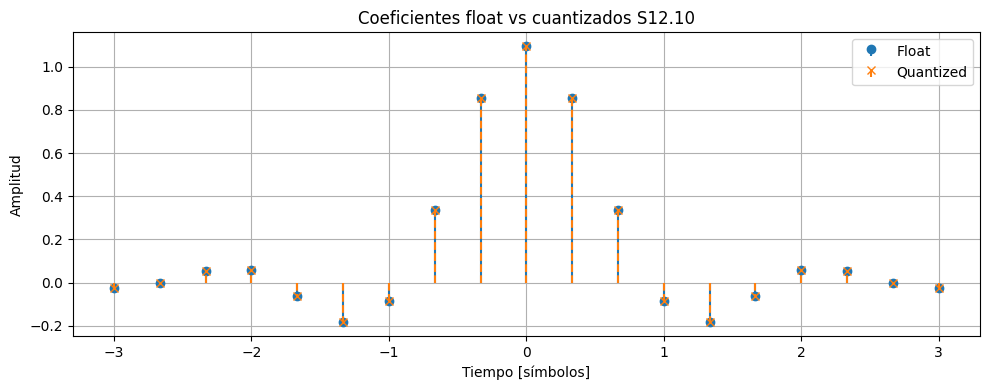

In [16]:
plt.figure(figsize=(10, 4))
plt.stem(t_symbols, h_float, linefmt="C0-", markerfmt="C0o", basefmt=" ")
plt.stem(t_symbols, h_q, linefmt="C1--", markerfmt="C1x", basefmt=" ")
plt.grid(True)
plt.xlabel("Tiempo [símbolos]")
plt.ylabel("Amplitud")
plt.title(f"Coeficientes float vs cuantizados S{NB_H}.{NBF_H}")
plt.legend(["Float", "Quantized"])
plt.tight_layout()
plt.show()

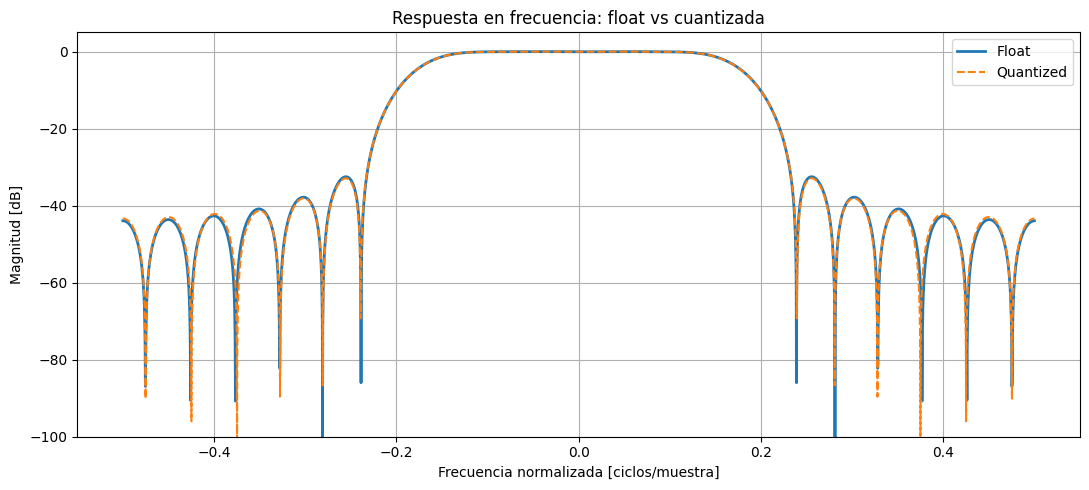

In [17]:
freq, H_float_db = compute_freq_response(h_float)

plt.figure(figsize=(11, 5))
plt.plot(freq, H_float_db, linewidth=2, label="Float")

_, H_q_db = compute_freq_response(h_q)
plt.plot(freq, H_q_db, linestyle="--", label="Quantized")

plt.grid(True)
plt.xlabel("Frecuencia normalizada [ciclos/muestra]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: float vs cuantizada")
plt.ylim([-100, 5])
plt.legend()
plt.tight_layout()
plt.show()

## Determinación de la precisión de salida

In [18]:
N_SYMBOLS_HIST = 512
N_TRIALS = 10000

rng = np.random.default_rng(seed=42)

max_values = []
min_values = []

for _ in range(N_TRIALS):
    # Símbolos PAM-2
    symbols = rng.choice([-1.0, 1.0], size=N_SYMBOLS_HIST)

    # Upsampling
    x = np.zeros(N_SYMBOLS_HIST * SPS)
    x[::SPS] = symbols

    # Salida del filtro RRC
    y = np.convolve(x, h_float)

    max_values.append(np.max(y))
    min_values.append(np.min(y))

max_values = np.array(max_values)
min_values = np.array(min_values)

print(f"Max observed   : {np.max(max_values):.6f}")
print(f"Min observed   : {np.min(min_values):.6f}")

Max observed   : 1.495530
Min observed   : -1.495530


## Generación de señales

In [19]:
# Formatos fixed-point elegidos
# Convención: Q(NB, NBF), signed, con NBI = NB - NBF incluyendo signo.

NB_I  = 2
NBF_I = 0

NB_O  = 12
NBF_O = 10

ROUNDING = "trunc"
OVERFLOW = "saturate"

fmt_i = FixedPointFormat(NB=NB_I, NBF=NBF_I)  # Entrada
fmt_o = FixedPointFormat(NB=NB_O, NBF=NBF_O)  # Salida

print("Formato de entrada")
fmt_i.info()

print("\nFormato de salida")
fmt_o.info()


Formato de entrada
Formato: Q(2, 0) signed
Bits enteros incluyendo signo: 2
Bits fraccionales           : 0
Resolución                  : 1.0
Rango entero                : [-2, 1]
Rango real                  : [-2.0, 1.0]

Formato de salida
Formato: Q(12, 10) signed
Bits enteros incluyendo signo: 2
Bits fraccionales           : 10
Resolución                  : 0.0009765625
Rango entero                : [-2048, 2047]
Rango real                  : [-2.0, 1.9990234375]


In [20]:
def export_hex(path, values, fmt):
    """
    Exporta enteros signed como hexadecimal en complemento a dos.
    """
    values_hex = fmt.to_hex(values)

    with open(path, "w") as f:
        for value in values_hex:
            f.write(f"{value}\n")


def export_float(path, values):
    """
    Exporta valores reales en texto.
    """
    values = np.asarray(values, dtype=float)

    with open(path, "w") as f:
        for value in values:
            f.write(f"{value:.6f}\n")

In [31]:
# Carpeta de exportación
EXPORT_DIR = Path("exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
DO_EXPORT = True

INPUT_TAG  = f"Q{fmt_i.NB}_{fmt_i.NBF}"
COEF_TAG   = f"Q{fmt_h.NB}_{fmt_h.NBF}"
OUTPUT_TAG = f"Q{fmt_o.NB}_{fmt_o.NBF}"

print(f"Directorio de exportación: {EXPORT_DIR}")
print(f"N_TAPS: {len(h_int)}")
print(f"Entrada      : {INPUT_TAG}")
print(f"Coeficientes : {COEF_TAG}")
print(f"Salida       : {OUTPUT_TAG}")


Directorio de exportación: exports
N_TAPS: 19
Entrada      : Q2_0
Coeficientes : Q12_10
Salida       : Q12_10


In [32]:
# Exportar coeficientes
coeffs_hex_path = EXPORT_DIR / f"coeffs_{COEF_TAG}.hex"
coeffs_q_float_path = EXPORT_DIR / f"coeffs_{COEF_TAG}_float_reference.txt"

if DO_EXPORT :
    export_hex(coeffs_hex_path, h_int, fmt_h)
    #export_float(coeffs_q_float_path, h_q)

    print(f"Exportado: {coeffs_hex_path}")
    #print(f"Exportado: {coeffs_q_float_path}")


Exportado: exports\coeffs_Q12_10.hex


In [33]:
# Señal de entrada: impulso unitario
N_IMPULSE = len(h_int) * 2

x_impulse = np.zeros(N_IMPULSE)
x_impulse[0] = 1.0

x_impulse_q, x_impulse_int = fmt_i.quantize(
    x_impulse,
    rounding=ROUNDING,
    overflow=OVERFLOW
)

impulse_hex_path = EXPORT_DIR / f"impulse_input_{INPUT_TAG}.hex"
impulse_q_float_path = EXPORT_DIR / f"impulse_input_{INPUT_TAG}_float_reference.txt"

if DO_EXPORT :
    export_hex(impulse_hex_path, x_impulse_int, fmt_i)
    #export_float(impulse_q_float_path, x_impulse_q)

    print(f"Exportado: {impulse_hex_path}")
    #print(f"Exportado: {impulse_q_float_path}")


Exportado: exports\impulse_input_Q2_0.hex


In [34]:
# Señal de entrada: secuencia PAM-2 upsampleada
N_SYMBOLS = 64

n_symbols = np.arange(N_SYMBOLS)

# Símbolos PAM-2: +1 / -1
symbols_pam2 = np.where(n_symbols % 2 == 0, 1.0, -1.0)

# Upsampling por SPS
N_PAM2 = N_SYMBOLS * SPS

x_pam2 = np.zeros(N_PAM2)
x_pam2[::SPS] = symbols_pam2

n_pam2 = np.arange(N_PAM2)

x_pam2_q, x_pam2_int = fmt_i.quantize(
    x_pam2,
    rounding=ROUNDING,
    overflow=OVERFLOW
)

pam2_hex_path = EXPORT_DIR / f"pam2_input_{INPUT_TAG}.hex"
pam2_q_float_path = EXPORT_DIR / f"pam2_input_{INPUT_TAG}_float_reference.txt"

if DO_EXPORT:
    export_hex(pam2_hex_path, x_pam2_int, fmt_i)
    # export_float(pam2_q_float_path, x_pam2_q)

    print(f"Exportado: {pam2_hex_path}")
    # print(f"Exportado: {pam2_q_float_path}")

Exportado: exports\pam2_input_Q2_0.hex


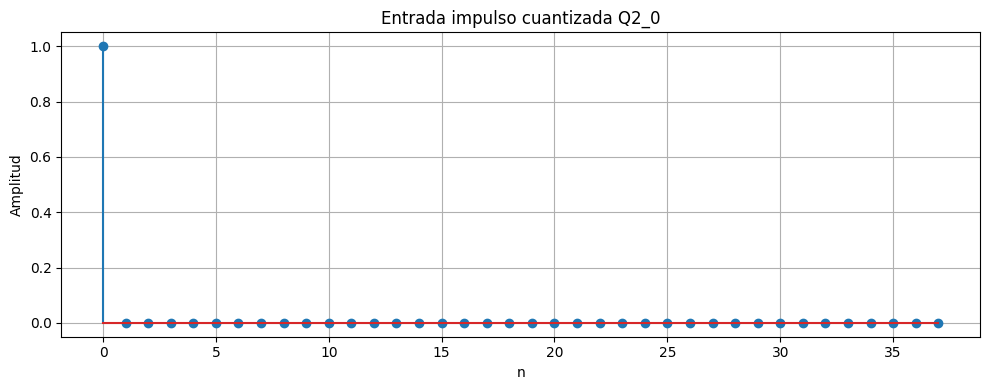

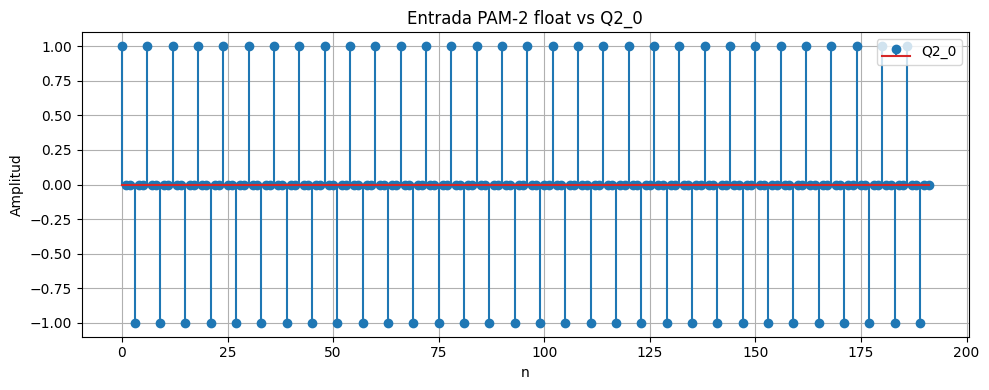

In [35]:
# Visualización de las señales de entrada exportadas

plt.figure(figsize=(10, 4))
plt.stem(x_impulse_q)
plt.grid(True)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title(f"Entrada impulso cuantizada {INPUT_TAG}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.stem(n_pam2, x_pam2_q,  label=INPUT_TAG)
plt.grid(True)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title(f"Entrada PAM-2 float vs {INPUT_TAG}")
plt.legend()
plt.tight_layout()
plt.show()

### Modelado de FIR con arimética de punto fijo

In [ ]:
def fir_fixed_model(i_data, i_taps, fmt_i, fmt_h, fmt_o):
    """
    Modelo FIR fixed-point estilo RTL con formatos independientes.

    Parámetros
    ----------
    i_data : array-like
        Señal de entrada en enteros escalados según fmt_i.
    i_taps : array-like
        Coeficientes en enteros escalados según fmt_h.
    fmt_i : FixedPointFormat
        Formato de entrada.
    fmt_h : FixedPointFormat
        Formato de coeficientes.
    fmt_o : FixedPointFormat
        Formato de salida. También se usa como formato intermedio
        al que se truncan/saturan las multiplicaciones antes del árbol de suma.

    Modelo aritmético
    -----------------
    - Entrada:      fmt_i
    - Coeficientes: fmt_h
    - Producto:     Q(fmt_i.NB + fmt_h.NB, fmt_i.NBF + fmt_h.NBF)
    - Producto truncado/saturado: fmt_o
    - Suma: deja crecer el ancho por sobrecarga de __add__
    - Salida final: fmt_o
    """
    x = [
        FixedPoint(value, fmt_i, from_int=True, overflow="raise")
        for value in i_data
    ]

    h = [
        FixedPoint(value, fmt_h, from_int=True, overflow="raise")
        for value in i_taps
    ]

    y = []

    # Convolución completa
    for n in range(len(x) + len(h) - 1):
        acc = FixedPoint(0, fmt_o, from_int=True, overflow="raise")

        for k in range(len(h)):  # Loop sobre taps
            x_idx = n - k

            if 0 <= x_idx < len(x):
                prod = x[x_idx] * h[k]  # Producto full precision

                # La precisión intermedia del FIR coincide con la precisión de salida.
                prod = prod.resize(
                    fmt_o,
                    rounding=ROUNDING,
                    overflow=OVERFLOW
                )

                acc = acc + prod

        y_n = acc.resize(
            fmt_o,
            rounding=ROUNDING,
            overflow=OVERFLOW
        )

        y.append(y_n)

    y_int = np.array([sample.int_value for sample in y], dtype=int)
    y_real = np.array([sample.real_value for sample in y], dtype=float)

    return y_int, y_real

In [37]:
y_impulse_int, y_impulse_real = fir_fixed_model(
    x_impulse_int,
    h_int,
    fmt_i=fmt_i,
    fmt_h=fmt_h,
    fmt_o=fmt_o
)

impulse_expected_hex_path = EXPORT_DIR / f"impulse_expected_{OUTPUT_TAG}.hex"
impulse_expected_float_path = EXPORT_DIR / f"impulse_expected_{OUTPUT_TAG}_float_reference.txt"

if DO_EXPORT :
    export_hex(impulse_expected_hex_path, y_impulse_int, fmt_o)
    #export_float(impulse_expected_float_path, y_impulse_real)

    print(f"Exportado: {impulse_expected_hex_path}")
    #print(f"Exportado: {impulse_expected_float_path}")


Exportado: exports\impulse_expected_Q12_10.hex


In [38]:
y_pam2_int, y_pam2_real = fir_fixed_model(
    x_pam2_int,
    h_int,
    fmt_i=fmt_i,
    fmt_h=fmt_h,
    fmt_o=fmt_o
)

pam2_expected_hex_path = EXPORT_DIR / f"pam2_expected_{OUTPUT_TAG}.hex"
pam2_expected_float_path = EXPORT_DIR / f"pam2_expected_{OUTPUT_TAG}_float_reference.txt"

if DO_EXPORT :

    export_hex(pam2_expected_hex_path, y_pam2_int, fmt_o)
    #export_float(pam2_expected_float_path, y_pam2_real)

    print(f"Exportado: {pam2_expected_hex_path}")
    #print(f"Exportado: {pam2_expected_float_path}")


Exportado: exports\pam2_expected_Q12_10.hex


In [40]:
print(np.max(y_impulse_real))
print(np.max(y_pam2_real))

1.0947265625
1.4267578125


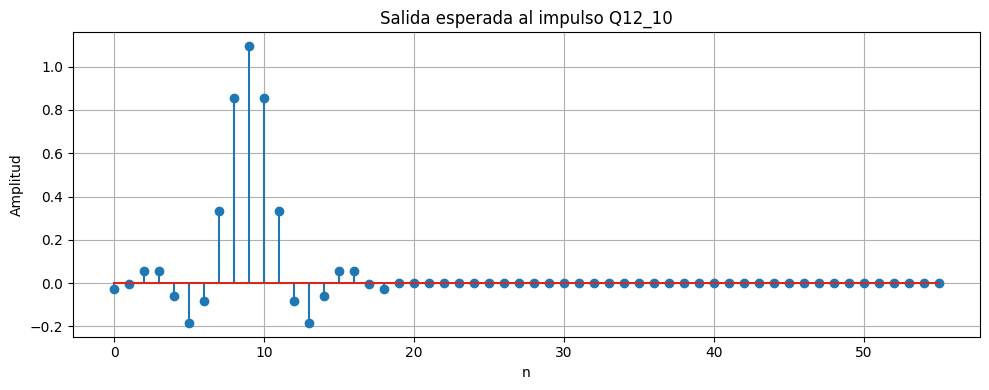

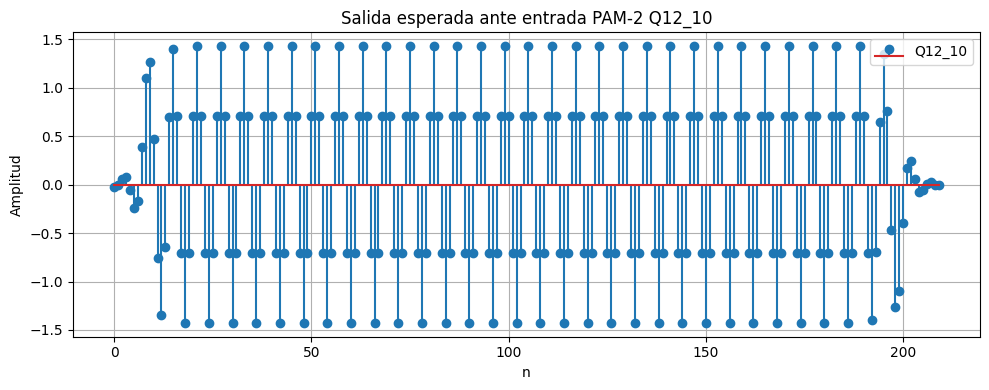

In [39]:
# Visualización de las salidas esperadas
plt.figure(figsize=(10, 4))
plt.stem(y_impulse_real)
plt.grid(True)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title(f"Salida esperada al impulso {OUTPUT_TAG}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.stem(y_pam2_real, label=OUTPUT_TAG)
plt.grid(True)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title(f"Salida esperada ante entrada PAM-2 {OUTPUT_TAG}")
plt.legend()
plt.tight_layout()
plt.show()
